---
title: xarray EOPF backend - Sentinel-1 Analysis Mode
subtitle: Learn how to access Sentinel-1 products in analysis mode
authors:
  - name: Konstantin Ntokas
    orcid: 0000-0002-0049-0690
    github: konstntokas
    affiliations:
      - id: Brockmann Consult GmbH
        institution: Brockmann Consult GmbH
        ror: 04r0k9g65
reviewers:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2026-07-22
thumbnail: ../static/EOPF-on-bright-baseline.png
keywords: ["data access", "xarray", "EOPF Zarr products"]
tags: ["sentinel-1", "xarray-eopf", "land"]
releaseDate: 2026-07-22
datePublished: 2026-07-22
dateModified: 2026-07-22
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of Contents
1. [Introduction](#Introduction_XEOPF_SEN1_ANALYSIS)
2. [Main Features](#Main_Features_XEOPF_SEN1_ANALYSIS)
3. [Import modules](#Import_XEOPF_SEN1_ANALYSIS)
4. [Open a Sentinel-1 Level-1 GRD](#Open_GRD_XEOPF_SEN1_ANALYSIS)
5. [Open a Sentinel-1 Level-1 SLC](#Open_SLC_XEOPF_SEN1_ANALYSIS)
6. [Open a Sentinel-1 Level-2 OCN](#Open_OCN_XEOPF_SEN1_ANALYSIS)
7. [Conclusion](#Conclusion_XEOPF_SEN1_ANALYSIS)

(Introduction_XEOPF_SEN1_ANALYSIS)=
## Introduction


**xarray-eopf** is a Python package that extends **xarray** with a custom backend called `"eopf-zarr"`. This backend enables **seamless access to ESA EOPF data products** stored in the **Zarr** format, presenting them as analysis-ready data structures.

In this notebook, we demonstrate how to use the **xarray-eopf** backend to access **Sentinel-1** EOPF Zarr products in **analysis mode**. All data access is *lazy*, meaning that data is only loaded when required—for example, during plotting or when writing to storage.

For a general introduction to the xarray EOPF backend, see the [introduction notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/introduction/).
For an example of the native mode, see the [Sentinel-1 native mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_1_native/).


- 🐙 **GitHub:** [EOPF Sample Service – xarray-eopf](https://github.com/EOPF-Sample-Service/xarray-eopf)
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xarray-eopf/issues)
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xarray-eopf/)

:::{hint} Overview
**Questions**
- How can I use the xarray-eopf backend for Sentinel-1 in anaylsis mode?
- What main features does the xarray-eopf backend provide for Sentinel-1 in analysis mode?

**Objectives**
- Learn how to open Sentinel-1 EOPF Zarr products using `xarray-eopf`.
- Understand the key features and capabilities of the `xarray-eopf` backend in analysis mode for Sentinel-1.
:::

(Main_Features_XEOPF_SEN1_ANALYSIS)=
## Main Features of the Analysis Mode for Sentinel-1

The Sentinel-1 analysis workflow supports:

- [**GRD products**](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-grd)
- [**SLC products**](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-slc)
- [**OCN products**](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l2-ocn)

### Sentinel-1 GRD

Sentinel-1 GRD products are provided in radar geometry with the coordinates
`azimuth_time` and `ground_range`. To generate an **analysis-ready dataset**, the
following processing steps are performed:

1. **Radiometric Calibration:** Raw pixel values (DN) are converted to calibrated backscatter using the `beta_nought` calibration lookup table (LUT).
2. **Geometric Terrain Correction (GTC):** The data is geocoded by inverse geocoding using satellite orbit information and a Digital Elevation Model (DEM). This involves solving the zero-Doppler equation to map radar coordinates onto a georeferenced grid.
3. **Radiometric Terrain Correction (RTC):** Optionally compensates for terrain-induced radiometric effects such as foreshortening, layover, and slope-dependent brightness variations.

**Reference**

📖 D. Small, *Flattening Gamma: Radiometric Terrain Correction for SAR Imagery*

### Sentinel-1 SLC

Sentinel-1 SLC products are provided as complex-valued bursts in radar geometry
with the coordinates `azimuth_time` and `slant_range_time`. To generate an
**analysis-ready dataset**, the following processing steps are performed:

1. **Radiometric Calibration:** Each burst is calibrated using the `beta_nought` calibration LUT. The complex-valued SLC data is converted to amplitude (`abs(slc)`).
2. **TOPSAR Debursting:** Individual bursts are aligned and merged into a continuous image. Burst overlaps are identified from the product metadata and removed.
3. **Geometric Terrain Correction (GTC):** Identical to the [GRD workflow](#sentinel-1-grd).
4. **Radiometric Terrain Correction (RTC):** Identical to the [GRD workflow](#sentinel-1-grd).

### Sentinel-1 OCN

Sentinel-1 OCN products are provided on a geographic swath grid, where each pixel
is defined by a latitude/longitude pair, forming a two-dimensional curvilinear
(irregular) grid.

Analysis mode applies the
[xcube-resampling rectification algorithm](https://xcube-dev.github.io/xcube-resampling/guide/#3-rectification)
to transform this irregular grid into a regular (rectilinear) grid with
one-dimensional latitude and longitude coordinates.

## Analysis Mode Features

The following features are available for all Sentinel-1 product types:

- **Default operation mode** for the `"eopf-zarr"` backend
- **Lazy processing** using Dask
- **Flexible variable selection** using explicit variable names or regular expressions
- **Configurable interpolation** via `interp_methods` (`nearest`, `bilinear`)

### Features specific to GRD and SLC

- **Flexible output grid definition**
  - Supply a DEM directly via the `dem` parameter (`xarray.DataArray`).
  - Or define the target grid using `crs`, `bbox`, and `resolution`.
  - If no DEM is supplied, the
    [CopDEM COG (30 m)](https://browser.stac.dataspace.copernicus.eu/collections/cop-dem-glo-30-dged-cog)
    is retrieved automatically via the CDSE STAC API (requires
    [CDSE S3 credentials](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets)).

- **Optional Radiometric Terrain Correction (RTC)** via `apply_rtc=False`.

- **Configurable radar footprint scaling** through `footprint_scale_factor`,
  which controls how radar pixels contribute to the output grid.
  - **GRD default:** `(3.0, 3.0)` to account for the resolution difference (e.g. ~10 m GRD vs. ~30 m DEM).
  - **SLC default:** `(3.0, 15.0)` to account for the resolution difference (e.g. ~10 m × ~2 m SLC vs. ~30 m DEM).

### Features specific to OCN

- **Rectification** from a 2D curvilinear grid to a rectilinear grid
- **Spatial subsetting** via `bbox`
- **Reprojection** to arbitrary CRSs via `crs` (default: WGS84 / EPSG:4326)

For a complete description of the available opening parameters, see the
[Analysis Mode documentation](https://eopf-sample-service.github.io/xarray-eopf/guide/#analysis-mode)
and the
[Sentinel-1 Analysis Mode guide](https://eopf-sample-service.github.io/xarray-eopf/guide/#sentinel-1).

---

(Import_XEOPF_SEN1_ANALYSIS)=
## Import Modules

The `eopf-zarr` backend is registered as an `xarray` plugin. Import `xarray` as usual, plus helper libraries used in this notebook.


In [1]:
import datetime
import os

import matplotlib.pyplot as plt
import pystac_client
import xarray as xr
from xcube_resampling.utils import reproject_bbox

---

(Open_GRD_XEOPF_SEN1_ANALYSIS)=
## Open a Sentinel-1 Level-1 GRD Product in Analysis Mode

We begin with an example that accesses a Sentinel-1 Level-1 GRD product in **analysis mode**.


### Find a Sentinel-1 GRD Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-grd) to search for a Sentinel-1 GRD tile.

In [2]:
%%time
bbox = [20.6, 37.6, 21.0, 38.0]
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-1-l1-grd"],
        bbox=bbox,
        datetime=[str(datetime.date.today() - datetime.timedelta(days=30)), None],
    ).items()
)
items

CPU times: user 31 ms, sys: 2 ms, total: 33 ms
Wall time: 1.62 s


[<Item id=S1D_IW_GRDH_1SDV_20260717T163121_20260717T163146_003716_006A72_8B2D>,
 <Item id=S1C_IW_GRDH_1SDV_20260717T043906_20260717T043931_008578_010FD0_A583>,
 <Item id=S1C_IW_GRDH_1SDV_20260716T163859_20260716T163924_008571_010F8C_7D8E>,
 <Item id=S1C_IW_GRDH_1SDV_20260711T163057_20260711T163122_008498_010D2F_A73D>,
 <Item id=S1D_IW_GRDH_1SDV_20260711T043919_20260711T043944_003621_006736_C9AC>,
 <Item id=S1D_IW_GRDH_1SDV_20260710T163924_20260710T163949_003614_006700_B3C3>,
 <Item id=S1D_IW_GRDH_1SDV_20260710T163859_20260710T163924_003614_006700_1481>,
 <Item id=S1D_IW_GRDH_1SDV_20260705T163120_20260705T163145_003541_006487_5456>,
 <Item id=S1D_IW_GRDH_1SDV_20260705T163055_20260705T163120_003541_006487_45CD>,
 <Item id=S1C_IW_GRDH_1SDV_20260705T043906_20260705T043931_008403_010A0D_E6E0>,
 <Item id=S1C_IW_GRDH_1SDV_20260704T163858_20260704T163923_008396_0109D0_A02C>,
 <Item id=S1C_IW_GRDH_1SDV_20260629T163056_20260629T163121_008323_01077A_7C35>,
 <Item id=S1D_IW_GRDH_1SDV_20260629T0439

In [3]:
item = items[1]
item

<Item id=S1C_IW_GRDH_1SDV_20260717T043906_20260717T043931_008578_010FD0_A583>

### Open Sentinel-1 GRD with default parameters

We can now open the Sentinel-1 product in **analysis mode**. Since this is the default, the `op_mode` parameter does not need to be specified.

The following cell returns a **lazy dataset**. For demonstration purposes, we restrict the data to a small spatial subset by specifying a bounding box.

Before proceeding, CDSE S3 credentials must be configured to enable access to the CopDEM (30 m) dataset from CDSE. Instructions for generating credentials are available [here](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets).

In [4]:
os.environ.update(
    {
        "AWS_ACCESS_KEY_ID": "xxx",
        "AWS_SECRET_ACCESS_KEY": "xxx",
    }
)

In [5]:
%%time
ds = xr.open_dataset(
    item.assets["product"].href, engine="eopf-zarr", bbox=bbox, chunks={}
)
ds

CPU times: user 5.25 s, sys: 1.32 s, total: 6.57 s
Wall time: 24.3 s


<xarray.Dataset> Size: 17MB
Dimensions:      (lat: 1441, lon: 1441)
Coordinates:
  * lat          (lat) float64 12kB 38.0 38.0 38.0 38.0 ... 37.6 37.6 37.6 37.6
  * lon          (lon) float64 12kB 20.6 20.6 20.6 20.6 ... 21.0 21.0 21.0 21.0
    spatial_ref  int64 8B ...
Data variables:
    gamma0_vv    (lat, lon) float32 8MB dask.array<chunksize=(1441, 1441), meta=np.ndarray>
    gamma0_vh    (lat, lon) float32 8MB dask.array<chunksize=(1441, 1441), meta=np.ndarray>

As an example, we plot the calibrated VV polarization band. Plotting triggers lazy loading and computation.

/home/konstantin/micromamba/envs/eopf-zarr/lib/python3.11/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


CPU times: user 2.47 s, sys: 518 ms, total: 2.99 s
Wall time: 4.18 s


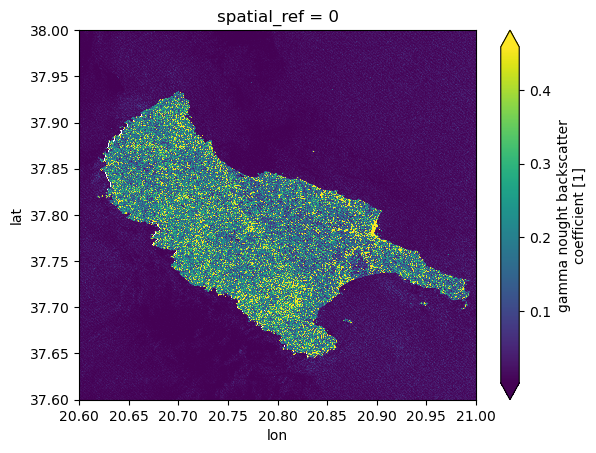

In [6]:
%%time
ds.gamma0_vv.plot(robust=True)

### Open Sentinel-1 GRD in UTM grid

In the following we show different ways to open a Sentinel-1 GRD product in analysis mode.

We can define the target gridmapping in UTM using the `resolution`, `crs`,and `bbox` parameters.


In [7]:
%%time
crs_utm = "EPSG:32631"
bbox_utm = reproject_bbox(bbox, "EPSG:4326", "EPSG:32631")

ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    bbox=bbox_utm,
    crs=crs_utm,
    resolution=30,  # meters
    chunks={},
)
ds

CPU times: user 7.59 s, sys: 1.5 s, total: 9.09 s
Wall time: 20.5 s


<xarray.Dataset> Size: 21MB
Dimensions:      (x: 1482, y: 1730)
Coordinates:
  * x            (x) float64 12kB 2.051e+06 2.051e+06 ... 2.095e+06 2.095e+06
  * y            (y) float64 14kB 4.362e+06 4.362e+06 ... 4.31e+06 4.31e+06
    spatial_ref  int64 8B ...
Data variables:
    gamma0_vv    (y, x) float32 10MB dask.array<chunksize=(1730, 1482), meta=np.ndarray>
    gamma0_vh    (y, x) float32 10MB dask.array<chunksize=(1730, 1482), meta=np.ndarray>

We can again visualize one polarization channel (for example `vv`).

CPU times: user 2.78 s, sys: 637 ms, total: 3.42 s
Wall time: 4.01 s


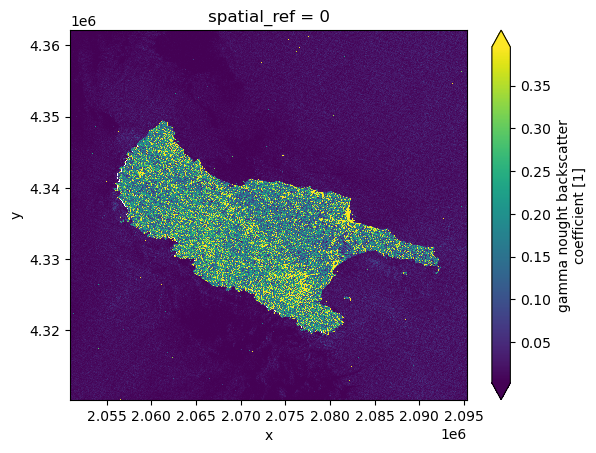

In [8]:
%%time
ds.gamma0_vv.plot(robust=True)

### Turn off radiometric terrain correction (RTC)

In the next example we turn off the RTC and select on the vv band.

In [9]:
%%time
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    bbox=bbox,
    variables=["vv"],
    apply_rtc=False,
    chunks={},
)
ds

CPU times: user 3.19 s, sys: 521 ms, total: 3.71 s
Wall time: 11.3 s


<xarray.Dataset> Size: 8MB
Dimensions:      (lat: 1441, lon: 1441)
Coordinates:
  * lat          (lat) float64 12kB 38.0 38.0 38.0 38.0 ... 37.6 37.6 37.6 37.6
  * lon          (lon) float64 12kB 20.6 20.6 20.6 20.6 ... 21.0 21.0 21.0 21.0
    spatial_ref  int64 8B ...
Data variables:
    beta0_vv     (lat, lon) float32 8MB dask.array<chunksize=(1441, 1441), meta=np.ndarray>

In the following plot you can clearly see the structure of the mountainous terrain, since the backscatter variation has not been corrected for the terrain.

CPU times: user 1.11 s, sys: 267 ms, total: 1.37 s
Wall time: 3.95 s


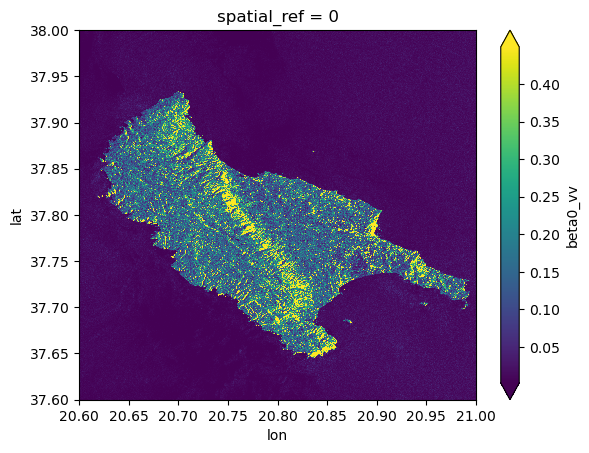

In [10]:
%%time
ds.beta0_vv.plot(robust=True)

### Interpolation Method: Nearest Neighbor

In the next example, we set the interpolation method to `nearest`, which is applied during both Geometric Terrain Correction (GTC) and Radiometric Terrain Correction (RTC).

This approach improves computational performance but reduces accuracy compared to bilinear interpolation, as it avoids spatial smoothing and instead assigns the value of the closest pixel.

In [11]:
%%time
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    bbox=bbox,
    interp_methods="nearest",
    chunks={},
)
ds

CPU times: user 3.74 s, sys: 796 ms, total: 4.54 s
Wall time: 13.8 s


<xarray.Dataset> Size: 17MB
Dimensions:      (lat: 1441, lon: 1441)
Coordinates:
  * lat          (lat) float64 12kB 38.0 38.0 38.0 38.0 ... 37.6 37.6 37.6 37.6
  * lon          (lon) float64 12kB 20.6 20.6 20.6 20.6 ... 21.0 21.0 21.0 21.0
    spatial_ref  int64 8B ...
Data variables:
    gamma0_vv    (lat, lon) float32 8MB dask.array<chunksize=(1441, 1441), meta=np.ndarray>
    gamma0_vh    (lat, lon) float32 8MB dask.array<chunksize=(1441, 1441), meta=np.ndarray>

CPU times: user 1.36 s, sys: 316 ms, total: 1.68 s
Wall time: 4.06 s


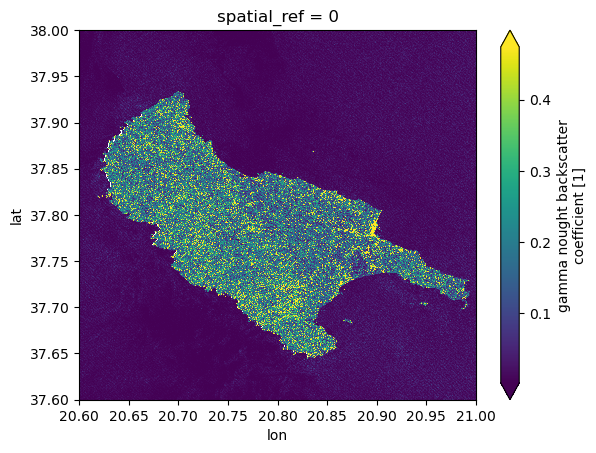

In [12]:
%%time
ds.gamma0_vv.plot(robust=True)

---

(Open_SLC_XEOPF_SEN1_ANALYSIS)=
## Open a Sentinel-1 Level-1 SLC Product in Analysis Mode

Next, we show an example that accesses a Sentinel-1 Level-2 SLC product in **analysis mode**.

### Find a Sentinel-1 SLC Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-slc) to search for a Sentinel-1 SLC tile.

In [13]:
%%time
bbox = [20.6, 37.6, 21.0, 38.0]
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-1-l1-slc"],
        bbox=bbox,
        datetime=["2026-05-04", "2026-05-04"],
        # datetime=[str(datetime.date.today() - datetime.timedelta(days=180)), None],
    ).items()
)
items

CPU times: user 24.1 ms, sys: 2.49 ms, total: 26.6 ms
Wall time: 222 ms


[<Item id=S1A_IW_SLC__1SDV_20260504T164002_20260504T164029_064370_081B0C_287A>]

In [14]:
item = items[0]
item

<Item id=S1A_IW_SLC__1SDV_20260504T164002_20260504T164029_064370_081B0C_287A>

In [15]:
%%time
ds = xr.open_dataset(
    item.assets["product"].href, engine="eopf-zarr", bbox=bbox, chunks={}
)
ds

CPU times: user 12.4 s, sys: 1.05 s, total: 13.4 s
Wall time: 1min 28s


<xarray.Dataset> Size: 17MB
Dimensions:      (lat: 1441, lon: 1441)
Coordinates:
  * lat          (lat) float64 12kB 38.0 38.0 38.0 38.0 ... 37.6 37.6 37.6 37.6
  * lon          (lon) float64 12kB 20.6 20.6 20.6 20.6 ... 21.0 21.0 21.0 21.0
    spatial_ref  int64 8B ...
Data variables:
    gamma0_vh    (lat, lon) float32 8MB dask.array<chunksize=(1441, 1441), meta=np.ndarray>
    gamma0_vv    (lat, lon) float32 8MB dask.array<chunksize=(1441, 1441), meta=np.ndarray>

As an example, we plot the calibrated VV polarization band. Plotting triggers lazy loading and computation.

CPU times: user 4.8 s, sys: 856 ms, total: 5.65 s
Wall time: 13.4 s


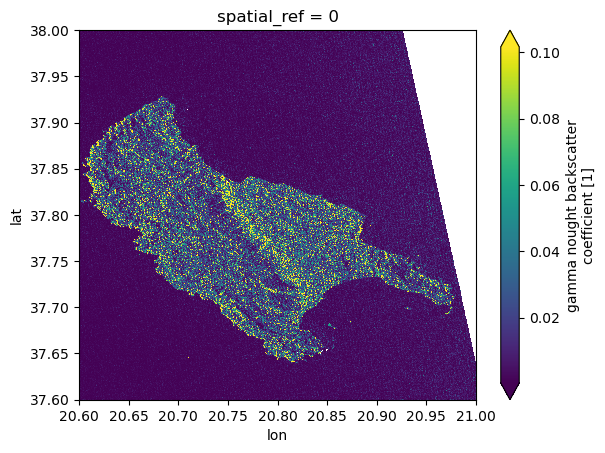

In [16]:
%%time
ds.gamma0_vv.plot(robust=True)

The same functionalities available for GRD products are also supported for SLC products, including the selection of different CRSs, bounding boxes, spatial resolutions, and interpolation methods.

---

(Open_OCN_XEOPF_SEN1_ANALYSIS)=
## Open a Sentinel-1 Level-2 OCN Product in Analysis Mode

Next, we show an example that accesses a Sentinel-1 Level-2 OCN product in **analysis mode**.

### Find a Sentinel-1 OCN Zarr Sample via STAC

To obtain a product URL, you can use the [STAC Browser](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l2-ocn) to search for a Sentinel-1 OCN tile.

In [17]:
%%time
bbox = [3.0, 39.4, 3.2, 39.6]
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
items = list(
    catalog.search(
        collections=["sentinel-1-l2-ocn"],
        bbox=bbox,
        datetime=[str(datetime.date.today() - datetime.timedelta(days=365)), None],
    ).items()
)
items

CPU times: user 23.7 ms, sys: 2.5 ms, total: 26.2 ms
Wall time: 208 ms


[<Item id=S1A_IW_OCN__2SDV_20250730T055348_20250730T055413_060309_077EBE_1CA3>]

In [18]:
item = items[0]

In [19]:
%%time
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    chunks={},
)
ds

CPU times: user 167 ms, sys: 4.03 ms, total: 171 ms
Wall time: 951 ms


<xarray.Dataset> Size: 874kB
Dimensions:                   (lon: 293, lat: 212)
Coordinates:
  * lon                       (lon) float64 2kB 1.09 1.101 1.113 ... 4.432 4.444
  * lat                       (lat) float64 2kB 40.63 40.62 ... 38.74 38.73
    spatial_ref               int64 8B ...
Data variables:
    wind_direction            (lat, lon) float32 248kB dask.array<chunksize=(212, 293), meta=np.ndarray>
    wind_speed                (lat, lon) float32 248kB dask.array<chunksize=(212, 293), meta=np.ndarray>
    inversion_quality         (lat, lon) uint8 62kB dask.array<chunksize=(212, 293), meta=np.ndarray>
    percentage_bright_points  (lat, lon) float32 248kB dask.array<chunksize=(212, 293), meta=np.ndarray>
    wind_quality              (lat, lon) uint8 62kB dask.array<chunksize=(212, 293), meta=np.ndarray>
Attributes: (2)

CPU times: user 270 ms, sys: 18.3 ms, total: 288 ms
Wall time: 477 ms


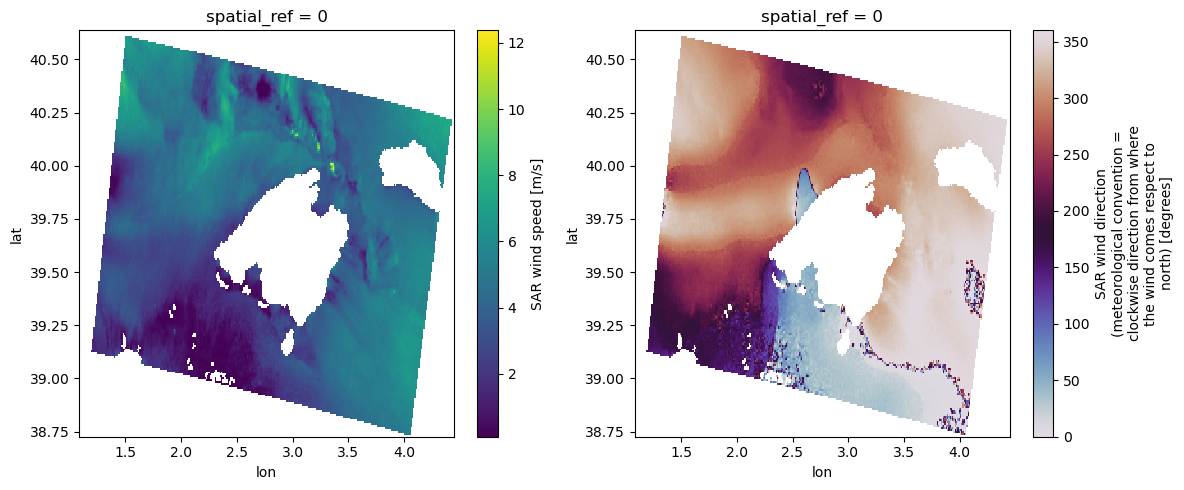

In [20]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ds.wind_speed.plot(ax=ax[0], cmap="viridis")
ds.wind_direction.plot(ax=ax[1], cmap="twilight", vmin=0, vmax=360)
plt.tight_layout()

We can also request the data in a different CRS, and define the target grid mapping by using the parameters `resolution`, and `bbox`.

In [21]:
%%time
ds = xr.open_dataset(
    item.assets["product"].href,
    engine="eopf-zarr",
    crs="EPSG:32631",
    resolution=1_000,  # meters
    bbox=[4e5, 4.3e6, 6e5, 4.5e6],
    variables=["wind_direction", "wind_speed"],
    chunks={},
)
ds

CPU times: user 297 ms, sys: 12.5 ms, total: 309 ms
Wall time: 1.19 s


<xarray.Dataset> Size: 323kB
Dimensions:         (x: 200, y: 200)
Coordinates:
  * x               (x) float64 2kB 4.005e+05 4.015e+05 ... 5.985e+05 5.995e+05
  * y               (y) float64 2kB 4.5e+06 4.498e+06 ... 4.302e+06 4.3e+06
    spatial_ref     int64 8B ...
Data variables:
    wind_direction  (y, x) float32 160kB dask.array<chunksize=(200, 200), meta=np.ndarray>
    wind_speed      (y, x) float32 160kB dask.array<chunksize=(200, 200), meta=np.ndarray>
Attributes: (2)

CPU times: user 169 ms, sys: 22.8 ms, total: 192 ms
Wall time: 253 ms


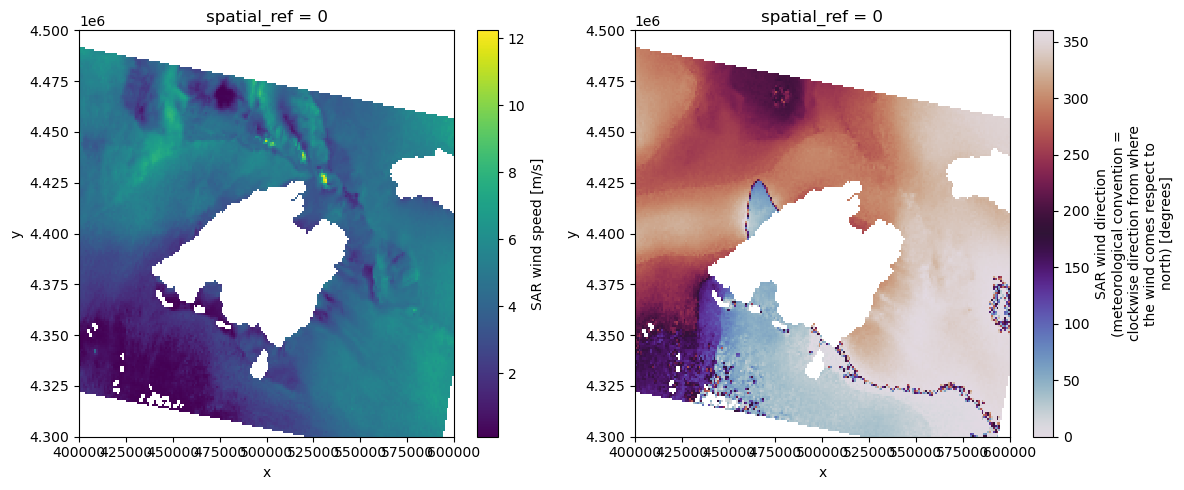

In [22]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ds.wind_speed.plot(ax=ax[0], cmap="viridis")
ds.wind_direction.plot(ax=ax[1], cmap="twilight", vmin=0, vmax=360)
plt.tight_layout()

---

(Conclusion_XEOPF_SEN1_ANALYSIS)=
## Conclusion

This notebook demonstrates how to access **Sentinel-1 EOPF Zarr** samples in **analysis mode** using the **xarray-eopf** plugin.

The main characteristics of analysis mode are:

- **Analysis mode** is the default `op_mode` and therefore does not need to be specified explicitly.
- Data is accessed lazily and processed on demand for a **user-defined CRS, bounding box, and spatial resolution**, enabling efficient subsetting, reprojection, and resampling.

### Sentinel-1 Level-1 GRD

The analysis workflow for **Sentinel-1 Level-1 GRD** includes:

- **Radiometric calibration** using the product LUTs.
- **Geometric Terrain Correction (GTC)** through inverse geocoding using orbit information and a DEM.
- Optional **Radiometric Terrain Correction (RTC)** to compensate for terrain-induced radiometric distortions.
- A DEM can either:
  - be provided explicitly by the user, or
  - be retrieved automatically from the CDSE STAC API and resampled to user-defined CRS, bounding box, and spatial resolution.
- If a DEM is provided, its grid definition determines the output grid.

### Sentinel-1 Level-1 SLC

The analysis workflow for **Sentinel-1 Level-1 SLC** includes:

- **Radiometric calibration** of each burst using the product LUTs.
- **TOPSAR debursting**, in which individual bursts are merged into a continuous image.
- **Geometric Terrain Correction (GTC)** through inverse geocoding using orbit information and a DEM.
- Optional **Radiometric Terrain Correction (RTC)** to compensate for terrain-induced radiometric distortions.
- A DEM can either:
  - be provided explicitly by the user, or
  - be retrieved automatically from the CDSE STAC API and resampled to user-defined CRS, bounding box, and spatial resolution.
- If a DEM is provided, its grid definition determines the output grid.
- Apart from the additional TOPSAR debursting step, the same configuration options as for GRD are available.

### Sentinel-1 Level-2 OCN

The analysis workflow for **Sentinel-1 Level-2 OCN** includes:

- Rectification from the native irregular latitude/longitude swath grid to a regular target grid.
- User-defined output grids via the `crs`, `bbox`, and `resolution` parameters.
- Automatic inclusion of quality flag variables by default.
- Optional variable selection using the `variables` parameter.

> **Note:** This notebook focuses exclusively on **analysis mode**. To learn more about **native mode**, see the [Sentinel-1 native mode notebook](https://eopf-sample-service.github.io/xarray-eopf/examples/sentinel_1_native/).

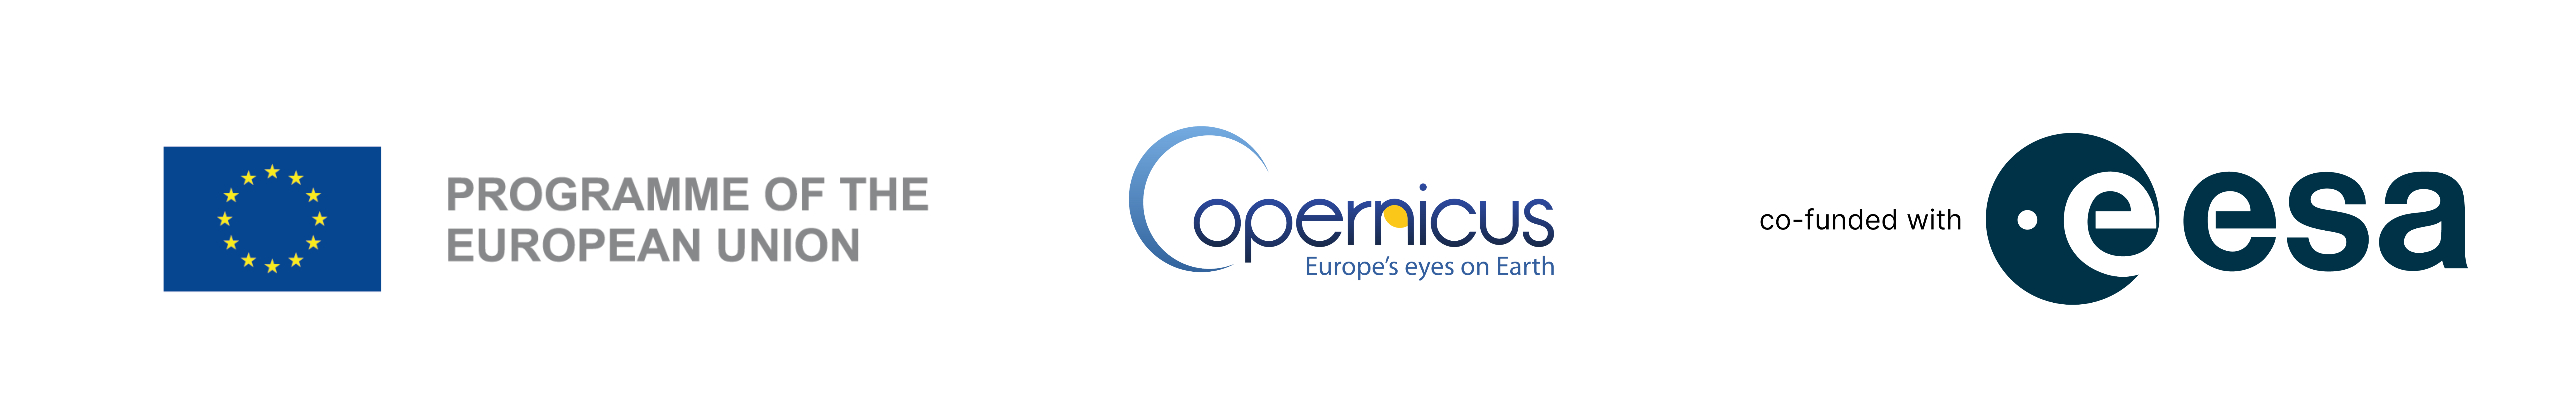